# Baseline com Batch Normalization — GTSRB
Exeperimento 2 - comparação da arquitetura Adam com e sem Batch Normalization

In [1]:
!pip install -q torch torchvision seaborn

### 1. SETUP

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
import copy
import json
from src.gtsrb import NUM_CLASSES, GTSRB_CLASSES, get_dataloaders, save_predictions

In [ ]:
model_pth_path = '/content/models_pth'
if not os.path.exists(model_pth_path):
  os.mkdir(model_pth_path)

figs_path = '/content/figs'
if not os.path.exists(figs_path):
    os.mkdir(figs_path)

checkpoints_path = '/content/checkpoints'
if not os.path.exists(checkpoints_path):
    os.mkdir(checkpoints_path)

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


### 2.Hiperparâmetros

In [4]:
IMG_SIZE = 32
BATCH_SIZE = 128
NUM_EPOCHS = 40
LR = 1e-3

In [5]:
train_loader, val_loader, test_loader = get_dataloaders(img_size=IMG_SIZE, batch_size=BATCH_SIZE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

100%|██████████| 187M/187M [00:22<00:00, 8.29MB/s]
100%|██████████| 89.0M/89.0M [00:09<00:00, 9.14MB/s]
100%|██████████| 99.6k/99.6k [00:00<00:00, 210kB/s]


Usando dispositivo: cuda


In [6]:
print(f"NUM_CLASSES = {NUM_CLASSES}")
print(f"train_loader = {len(train_loader)} batches")
print(f"val_loader = {len(val_loader)} batches")
print(f"test_loader = {len(test_loader)} batches")

for x, y in train_loader:
    print("Formato das imagens:", x.shape)
    print("Formato dos rótulos:", y.shape)
    break

NUM_CLASSES = 43
train_loader = 167 batches
val_loader = 42 batches
test_loader = 99 batches
Formato das imagens: torch.Size([128, 3, 32, 32])
Formato dos rótulos: torch.Size([128])


### 3.Modelo rede neural


### 3.1 Classe para Rede Neural COM Batch Normalization

In [7]:
class EHMNet_BN(nn.Module):
    def __init__(self, num_classes: int = 43, img_size: int = 32):
        super(EHMNet_BN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=1, padding='same')
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding='same')
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        spatial = img_size // 4
        flatten_size = 64 * spatial * spatial
        self.fc1 = nn.Linear(in_features=flatten_size, out_features=256)
        self.fc2 = nn.Linear(in_features=256, out_features=num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = torch.relu(x)
        x = self.pool1(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = torch.relu(x)
        x = self.pool2(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = torch.relu(x)
        x = self.fc2(x)
        return x

### 3.2 Classe para Rede Neural SEM Batch Normalization

In [8]:
class EHMNet(nn.Module):
    def __init__(self, num_classes: int = 43, img_size: int = 32):
        super(EHMNet, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=1, padding='same')
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding='same')
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        spatial = img_size // 4
        flatten_size = 64 * spatial * spatial
        self.fc1 = nn.Linear(in_features=flatten_size, out_features=256)
        self.fc2 = nn.Linear(in_features=256, out_features=num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = torch.relu(x)
        x = self.pool1(x)
        x = self.conv2(x)
        x = torch.relu(x)
        x = self.pool2(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = torch.relu(x)
        x = self.fc2(x)
        return x

### 4.Funções para Cálculo e Compara das Métricas

In [9]:
def train_one_epoch(trainloader,model,criterion,optimizer,device) -> tuple[float,float]:
    total_loss,correct,total  = 0.0, 0, 0

    for images, labels in trainloader:
      images, labels = images.to(device), labels.to(device)

      optimizer.zero_grad()
      outputs = model(images)
      loss = criterion(outputs, labels)
      loss.backward()
      optimizer.step()

      total_loss += loss.item() * images.size(0)
      correct += (outputs.argmax(dim=1) == labels).sum().item()
      total += labels.size(0)

    return total_loss/total, correct/total

def validate(val_loader,model,criterion,device) -> tuple[float,float]:
  total_loss,correct,total  = 0.0, 0, 0

  with torch.no_grad():
    for images, labels in val_loader:
      images, labels = images.to(device), labels.to(device)

      outputs = model(images)
      loss = criterion(outputs, labels)

      total_loss += loss.item() * images.size(0)
      correct += (outputs.argmax(dim=1) == labels).sum().item()
      total += labels.size(0)

  return total_loss/total, correct/total

def get_confusion_matrix(loader, model, device, num_class=NUM_CLASSES) -> torch.Tensor:
  model.eval()
  cm = torch.zeros(num_class, num_class, dtype=torch.int64)

  with torch.no_grad():
      for images, labels in loader:
          images, labels = images.to(device), labels.to(device)
          outputs = model(images)
          _, predicted = torch.max(outputs.data, 1)
          for t, p in zip(labels, predicted):
              cm[t, p] += 1
  return cm

def plot_confusion_matrix(cm, title='Matriz de Confusão', save_path=None, ax=None):
    nomes_classes = [GTSRB_CLASSES[i] for i in range(NUM_CLASSES)]
    standalone = ax is None
    if standalone:
        plt.figure(figsize=(12, 10))
        ax = plt.gca()

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=nomes_classes, yticklabels=nomes_classes, ax=ax)

    ax.set_ylabel('Valores Reais')
    ax.set_xlabel('Valores Previstos')
    ax.set_title(title)

    if standalone:
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()


def predict(loader, model, device):
    model.eval()
    ytrue, ypred = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            pred = model(images).argmax(1).cpu().numpy()
            ytrue.append(labels.numpy())
            ypred.append(pred)
    return np.concatenate(ytrue), np.concatenate(ypred)


def per_class_accuracy(y_true, y_pred, num_classes=NUM_CLASSES) -> torch.Tensor:
    accs = torch.zeros(num_classes)
    for c in range(num_classes):
        mask = (y_true == c)
        total = float(mask.sum())
        accs[c] = float((y_pred[mask] == c).sum()) / total if total > 0 else float('nan')
    return accs


### Funções de salvamento e carregamento de modelos


In [10]:
def save_model_state(state_dict, file_name, path=model_pth_path):
    PATH = f'{path}/{file_name}'
    torch.save(state_dict, PATH)
    return PATH

In [11]:
def load_model(file_name, model_class, path=model_pth_path, **kwargs):
    PATH = f'{path}/{file_name}'
    model = model_class(**kwargs)
    model.load_state_dict(torch.load(PATH))
    return model

### 5.Função de treino completo (BN e Sem BN)

In [12]:
def run_experiment(model, model_name, train_loader, val_loader, num_epochs, lr, device):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0.0
    best_epoch = 0
    best_state = None

    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_one_epoch(train_loader, model, criterion, optimizer, device)
        val_loss, val_acc = validate(val_loader, model, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())

        if epoch % 3 == 0 or epoch == 1:
            print(f"[{model_name}] Epoch {epoch:02d}/{num_epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    checkpoint_path = save_model_state(best_state, f"{model_name}.pt")

    best_model = model.__class__(num_classes=NUM_CLASSES, img_size=IMG_SIZE).to(device)
    best_model.load_state_dict(best_state)
    best_model.eval()

    print(f"\nMelhor acurácia de validação: {best_val_acc:.4f} (época {best_epoch})")

    return {
        "name": model_name,
        "model": best_model,
        "history": history,
        "checkpoint_path": checkpoint_path,
        "best_val_acc": best_val_acc,
        "best_epoch": best_epoch,
    }


### 6.Experimento 2- Treinando SEM Batch Normalization



In [13]:
model_no_bn = EHMNet(num_classes=NUM_CLASSES, img_size=IMG_SIZE).to(device)
res_no_bn = run_experiment(model_no_bn, "ehmnet_no_bn", train_loader, val_loader, NUM_EPOCHS, LR, device)


[ehmnet_no_bn] Epoch 01/40 | Train Loss: 1.5713 | Train Acc: 0.5687 | Val Loss: 0.4248 | Val Acc: 0.8956
[ehmnet_no_bn] Epoch 03/40 | Train Loss: 0.1065 | Train Acc: 0.9726 | Val Loss: 0.0824 | Val Acc: 0.9794
[ehmnet_no_bn] Epoch 06/40 | Train Loss: 0.0262 | Train Acc: 0.9931 | Val Loss: 0.0483 | Val Acc: 0.9878
[ehmnet_no_bn] Epoch 09/40 | Train Loss: 0.0069 | Train Acc: 0.9988 | Val Loss: 0.0349 | Val Acc: 0.9906
[ehmnet_no_bn] Epoch 12/40 | Train Loss: 0.0061 | Train Acc: 0.9989 | Val Loss: 0.0380 | Val Acc: 0.9921
[ehmnet_no_bn] Epoch 15/40 | Train Loss: 0.0009 | Train Acc: 0.9999 | Val Loss: 0.0376 | Val Acc: 0.9925
[ehmnet_no_bn] Epoch 18/40 | Train Loss: 0.0600 | Train Acc: 0.9838 | Val Loss: 0.0553 | Val Acc: 0.9867
[ehmnet_no_bn] Epoch 21/40 | Train Loss: 0.0014 | Train Acc: 0.9999 | Val Loss: 0.0317 | Val Acc: 0.9957
[ehmnet_no_bn] Epoch 24/40 | Train Loss: 0.0001 | Train Acc: 1.0000 | Val Loss: 0.0320 | Val Acc: 0.9959
[ehmnet_no_bn] Epoch 27/40 | Train Loss: 0.0001 | Train

### 6. Experimento 2- Treinando COM Batch Normalization

In [14]:
model_bn = EHMNet_BN(num_classes=NUM_CLASSES, img_size=IMG_SIZE).to(device)
res_bn = run_experiment(model_bn, "ehmnet_bn", train_loader, val_loader, NUM_EPOCHS, LR, device)



[ehmnet_bn] Epoch 01/40 | Train Loss: 1.1915 | Train Acc: 0.6807 | Val Loss: 0.2775 | Val Acc: 0.9405
[ehmnet_bn] Epoch 03/40 | Train Loss: 0.0727 | Train Acc: 0.9865 | Val Loss: 0.0642 | Val Acc: 0.9861
[ehmnet_bn] Epoch 06/40 | Train Loss: 0.0446 | Train Acc: 0.9891 | Val Loss: 0.0777 | Val Acc: 0.9786
[ehmnet_bn] Epoch 09/40 | Train Loss: 0.0228 | Train Acc: 0.9942 | Val Loss: 0.0342 | Val Acc: 0.9917
[ehmnet_bn] Epoch 12/40 | Train Loss: 0.0015 | Train Acc: 1.0000 | Val Loss: 0.0197 | Val Acc: 0.9959
[ehmnet_bn] Epoch 15/40 | Train Loss: 0.0008 | Train Acc: 1.0000 | Val Loss: 0.0196 | Val Acc: 0.9949
[ehmnet_bn] Epoch 18/40 | Train Loss: 0.0005 | Train Acc: 1.0000 | Val Loss: 0.0196 | Val Acc: 0.9959
[ehmnet_bn] Epoch 21/40 | Train Loss: 0.0470 | Train Acc: 0.9866 | Val Loss: 0.0477 | Val Acc: 0.9880
[ehmnet_bn] Epoch 24/40 | Train Loss: 0.0009 | Train Acc: 1.0000 | Val Loss: 0.0204 | Val Acc: 0.9962
[ehmnet_bn] Epoch 27/40 | Train Loss: 0.0004 | Train Acc: 1.0000 | Val Loss: 0.018

# ANALISE DE RESULTADOS E GRAFICOS

### 1. Comparando as curvas de treino

In [ ]:
all_results = {"no_bn": res_no_bn, "bn": res_bn}

to_save = {
    name: {k: v for k, v in r.items() if k not in ["ckpt_path", "model"]}
    for name, r in all_results.items()
}

with open(f"checkpoints/exp2_{NUM_EPOCHS}_summary.json", "w") as f:
    json.dump(to_save, f, indent=2, default=float)
print("Resumo salvo em checkpoints/exp.json")

Resumo salvo em checkpoints/exp.json


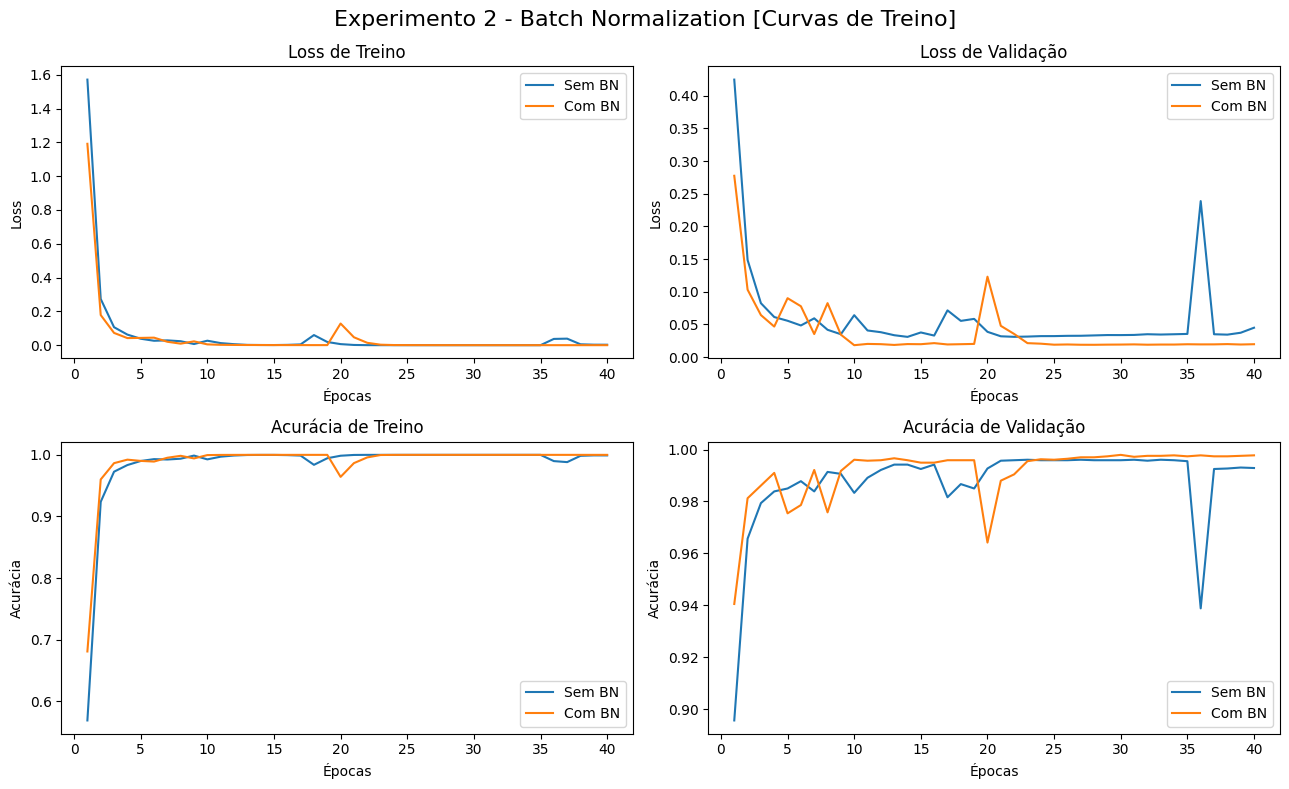

In [ ]:
labels = {"no_bn": "Sem BN", "bn": "Com BN"}
colors = {"no_bn": "tab:blue", "bn": "tab:orange"}

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
epochs = range(1, NUM_EPOCHS + 1)

for name, r in all_results.items():
    axes[0, 0].plot(epochs, r["history"]["train_loss"], label=labels[name], color=colors[name])
axes[0, 0].set_title("Loss de Treino"); axes[0, 0].set_xlabel("Épocas"); axes[0, 0].set_ylabel("Loss"); axes[0, 0].legend()

for name, r in all_results.items():
    axes[0, 1].plot(epochs, r["history"]["val_loss"], label=labels[name], color=colors[name])
axes[0, 1].set_title("Loss de Validação"); axes[0, 1].set_xlabel("Épocas"); axes[0, 1].set_ylabel("Loss"); axes[0, 1].legend()

for name, r in all_results.items():
    axes[1, 0].plot(epochs, r["history"]["train_acc"], label=labels[name], color=colors[name])
axes[1, 0].set_title("Acurácia de Treino"); axes[1, 0].set_xlabel("Épocas"); axes[1, 0].set_ylabel("Acurácia"); axes[1, 0].legend()

for name, r in all_results.items():
    axes[1, 1].plot(epochs, r["history"]["val_acc"], label=labels[name], color=colors[name])
axes[1, 1].set_title("Acurácia de Validação"); axes[1, 1].set_xlabel("Épocas"); axes[1, 1].set_ylabel("Acurácia"); axes[1, 1].legend()

plt.suptitle("Experimento 2 - Batch Normalization [Curvas de Treino]", fontsize=16)
plt.tight_layout()
plt.savefig(f"figs/curvas_treino_bn_{NUM_EPOCHS}Epochs.png", dpi=150, bbox_inches="tight")
plt.show()


### 2. Matrizes de confusão dos dois modelos

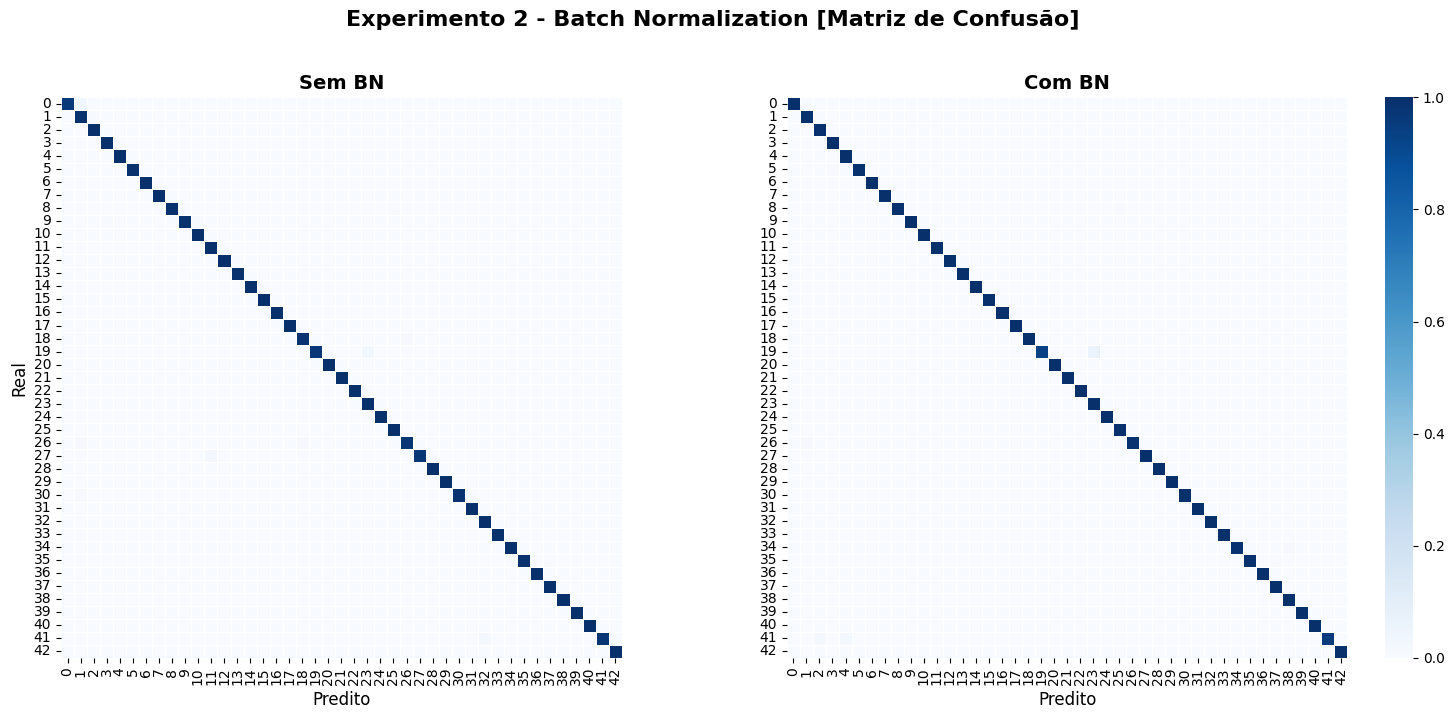

In [ ]:
cm = {name: get_confusion_matrix(val_loader, r["model"], device, NUM_CLASSES).cpu().numpy()
      for name, r in all_results.items()}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for i, name in enumerate(["no_bn", "bn"]):
    cm_norm = cm[name].astype(float) / cm[name].sum(axis=1, keepdims=True)
    sns.heatmap(
        cm_norm, annot=False,
        xticklabels=np.arange(NUM_CLASSES), yticklabels=np.arange(NUM_CLASSES),
        ax=axes[i], cmap="Blues", cbar=(i == 1), vmin=0, vmax=1,
        linewidths=0.5, linecolor="white", square=True,
    )
    axes[i].set_title(labels[name], fontsize=14, fontweight="bold")
    axes[i].set_xlabel("Predito", fontsize=12)
    axes[i].set_ylabel("Real" if i == 0 else "", fontsize=12)
    axes[i].tick_params(labelsize=10)

plt.suptitle("Experimento 2 - Batch Normalization [Matriz de Confusão]", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"figs/matrizes_confusao_comparacao_{NUM_EPOCHS}Epochs.png", dpi=150, bbox_inches="tight")
plt.show()


### 3. Acurácia por classe e macro accuracy

In [22]:
import pandas as pd

def relatorio_por_classe(cm, class_names=GTSRB_CLASSES, nome_modelo=""):
    """Calcula acurácia por classe (recall), acurácia global e macro accuracy.

    A matriz de confusão tem linhas = classe real e colunas = classe predita,
    então a acurácia de cada classe é diagonal / soma da linha.
    """
    cm = cm.numpy() if hasattr(cm, "numpy") else np.asarray(cm)
    suporte = cm.sum(axis=1)
    acertos = np.diag(cm)
    acc_classe = np.divide(acertos, suporte,
                           out=np.zeros(len(cm), dtype=float), where=suporte > 0)

    overall = acertos.sum() / cm.sum()
    macro_acc = acc_classe.mean()

    df = pd.DataFrame({
        "classe":   [class_names[i] for i in range(len(cm))],
        "suporte":  suporte.astype(int),
        "acertos":  acertos.astype(int),
        "acuracia": acc_classe.round(4),
    })

    print(f"=== {nome_modelo} ===")
    print(f"Acurácia global (overall): {overall:.4f}")
    print(f"Macro accuracy (média por classe): {macro_acc:.4f}\n")
    print("5 piores classes:")
    print(df.sort_values("acuracia").head(5).to_string(index=False))
    print()
    return df, overall, macro_acc

relatorios = {}
for name in ["no_bn", "bn"]:
    relatorios[name] = relatorio_por_classe(cm[name], nome_modelo=labels[name])


=== Sem BN ===
Acurácia global (overall): 0.9961
Macro accuracy (média por classe): 0.9947

5 piores classes:
              classe  suporte  acertos  acuracia
Speed limit (20km/h)       26       25    0.9615
Dangerous curve left       31       30    0.9677
         Pedestrians       34       33    0.9706
   End of no passing       40       39    0.9750
     Traffic signals       83       81    0.9759

=== Com BN ===
Acurácia global (overall): 0.9968
Macro accuracy (média por classe): 0.9957

5 piores classes:
              classe  suporte  acertos  acuracia
Dangerous curve left       31       29    0.9355
   End of no passing       40       38    0.9500
     Turn left ahead       68       67    0.9853
     Traffic signals       83       82    0.9880
Speed limit (80km/h)      257      254    0.9883



In [23]:
metrics_results = {}

for name, r in all_results.items():
    ytrue, ypred = predict(val_loader, r["model"], device)

    per_class_acc = per_class_accuracy(ytrue, ypred)
    global_acc = float((ypred == ytrue).mean())
    macro_acc = float(per_class_acc.mean())

    metrics_results[name] = {
        "ytrue": ytrue,
        "ypred": ypred,
        "per_class_acc": per_class_acc,
        "global_acc": global_acc,
        "macro_acc": macro_acc,
    }

    print(f"{labels[name]}:")
    print(f"  Acurácia Global: {global_acc:.4f}")
    print(f"  Acurácia Macro:  {macro_acc:.4f}\n")


Sem BN:
  Acurácia Global: 0.9961
  Acurácia Macro:  0.9947

Com BN:
  Acurácia Global: 0.9968
  Acurácia Macro:  0.9957



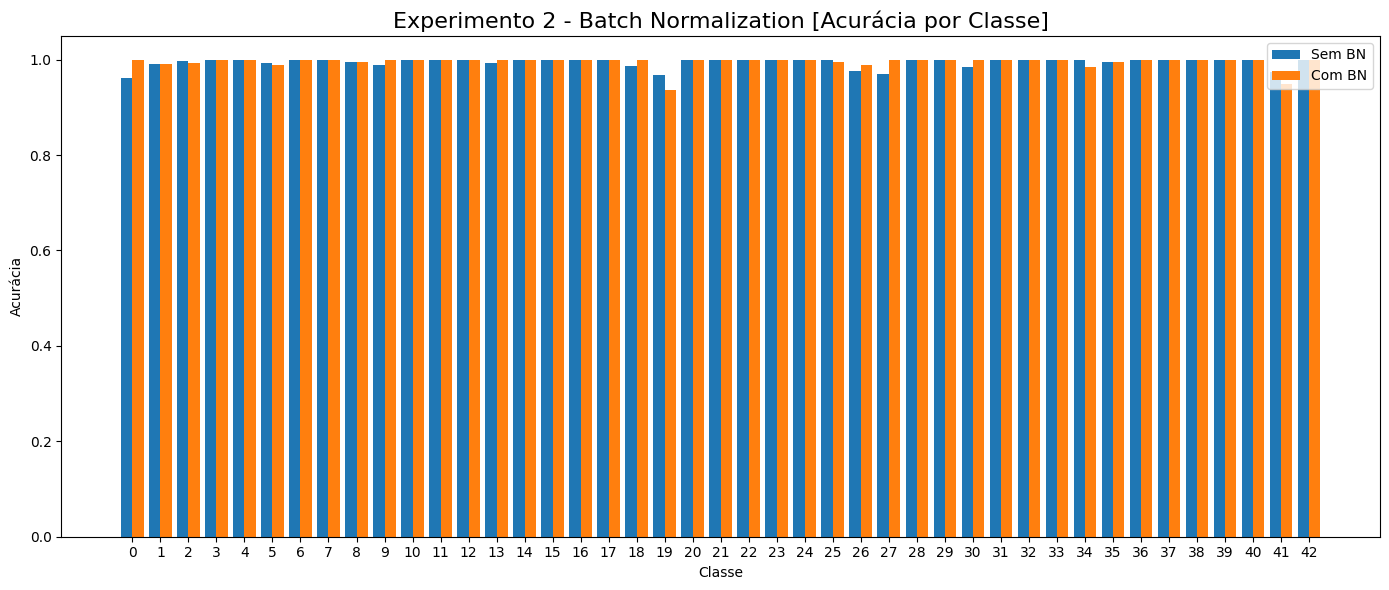

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
n_series = len(metrics_results)
width = 0.8 / n_series
x = np.arange(NUM_CLASSES)

for i, (name, r) in enumerate(metrics_results.items()):
    offset = (i - (n_series - 1) / 2) * width
    ax.bar(x + offset, r["per_class_acc"], width=width, label=labels[name], color=colors[name])

ax.set_xlabel("Classe")
ax.set_ylabel("Acurácia")
ax.set_title("Experimento 2 - Batch Normalization [Acurácia por Classe]", fontsize=16)
ax.set_xticks(x)
ax.legend()
plt.tight_layout()
plt.savefig(f"figs/acuracia_por_classe_bn_{NUM_EPOCHS}Epochs.png", dpi=150, bbox_inches="tight")
plt.show()


### 4. Predições no conjunto de teste

In [25]:
def predict_test_set(test_loader, model, device):
    model.eval()
    predictions = []
    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1).cpu().numpy()
            predictions.extend(preds)
    return predictions

y_pred_no_bn = predict_test_set(test_loader, all_results["no_bn"]["model"], device)
save_predictions(y_pred_no_bn, "predicoes_no_bn.csv", experiment_name="EHMNet sem BatchNorm")

y_pred_bn = predict_test_set(test_loader, all_results["bn"]["model"], device)
save_predictions(y_pred_bn, "predicoes_bn.csv", experiment_name="EHMNet com BatchNorm")


# Métricas oficiais no conjunto de TESTE (avaliação final)

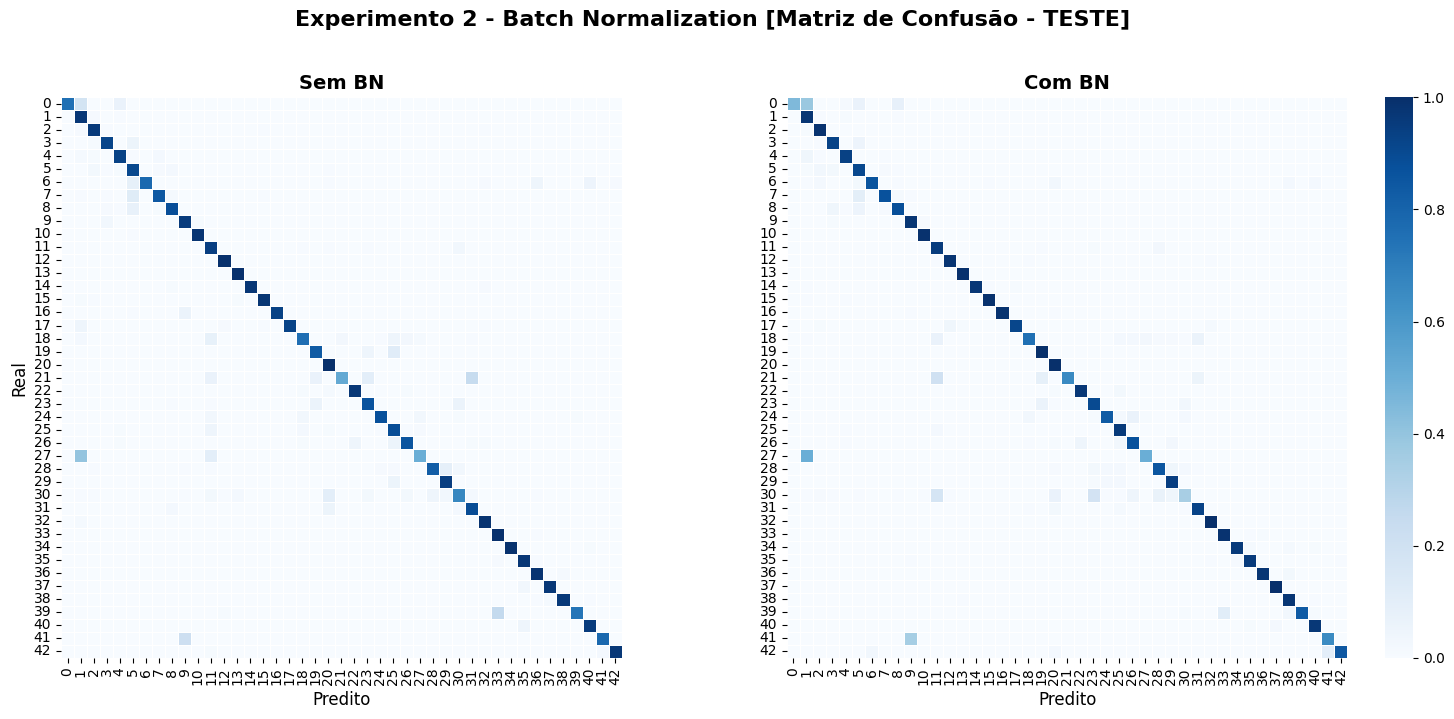

In [29]:
cm_test = {name: get_confusion_matrix(test_loader, r["model"], device, NUM_CLASSES).cpu().numpy()
           for name, r in all_results.items()}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for i, name in enumerate(["no_bn", "bn"]):
    cm_norm = cm_test[name].astype(float) / cm_test[name].sum(axis=1, keepdims=True)
    sns.heatmap(
        cm_norm, annot=False,
        xticklabels=np.arange(NUM_CLASSES), yticklabels=np.arange(NUM_CLASSES),
        ax=axes[i], cmap="Blues", cbar=(i == 1), vmin=0, vmax=1,
        linewidths=0.5, linecolor="white", square=True,
    )
    axes[i].set_title(labels[name], fontsize=14, fontweight="bold")
    axes[i].set_xlabel("Predito", fontsize=12)
    axes[i].set_ylabel("Real" if i == 0 else "", fontsize=12)
    axes[i].tick_params(labelsize=10)

plt.suptitle("Experimento 2 - Batch Normalization [Matriz de Confusão - TESTE]", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("figs2/matrizes_confusao_teste.png", dpi=150, bbox_inches="tight")
plt.show()


In [28]:
relatorios_teste = {}
for name in ["no_bn", "bn"]:
    relatorios_teste[name] = relatorio_por_classe(cm_test[name], nome_modelo=f"{labels[name]} (TESTE)")

metrics_results_teste = {}
for name, r in all_results.items():
    ytrue, ypred = predict(test_loader, r["model"], device)
    per_class_acc = per_class_accuracy(ytrue, ypred)
    global_acc = float((ypred == ytrue).mean())
    macro_acc = float(per_class_acc.mean())
    metrics_results_teste[name] = {
        "ytrue": ytrue,
        "ypred": ypred,
        "per_class_acc": per_class_acc,
        "global_acc": global_acc,
        "macro_acc": macro_acc,
    }
    print(f"{labels[name]} (TESTE):")
    print(f"  Acurácia Global: {global_acc:.4f}")
    print(f"  Acurácia Macro:  {macro_acc:.4f}\n")

# Resumo comparando validacao x teste -- esse e o numero que vai pro relatorio
resumo_final = pd.DataFrame({
    "modelo": [labels["no_bn"], labels["bn"]],
    "acuracia_global_val":   [round(metrics_results["no_bn"]["global_acc"], 4), round(metrics_results["bn"]["global_acc"], 4)],
    "acuracia_global_teste": [round(metrics_results_teste["no_bn"]["global_acc"], 4), round(metrics_results_teste["bn"]["global_acc"], 4)],
    "macro_accuracy_val":    [round(metrics_results["no_bn"]["macro_acc"], 4), round(metrics_results["bn"]["macro_acc"], 4)],
    "macro_accuracy_teste":  [round(metrics_results_teste["no_bn"]["macro_acc"], 4), round(metrics_results_teste["bn"]["macro_acc"], 4)],
})
print(resumo_final.to_string(index=False))


=== Sem BN (TESTE) ===
Acurácia global (overall): 0.9239
Macro accuracy (média por classe): 0.8913

5 piores classes:
              classe  suporte  acertos  acuracia
         Pedestrians       60       30    0.5000
        Double curve       90       47    0.5222
  Beware of ice/snow      150      100    0.6667
           Keep left       90       66    0.7333
Speed limit (20km/h)       60       45    0.7500

=== Com BN (TESTE) ===
Acurácia global (overall): 0.9286
Macro accuracy (média por classe): 0.8885

5 piores classes:
              classe  suporte  acertos  acuracia
  Beware of ice/snow      150       52    0.3467
Speed limit (20km/h)       60       27    0.4500
         Pedestrians       60       30    0.5000
   End of no passing       60       39    0.6500
        Double curve       90       59    0.6556

Sem BN (TESTE):
  Acurácia Global: 0.9239
  Acurácia Macro:  0.8913

Com BN (TESTE):
  Acurácia Global: 0.9286
  Acurácia Macro:  0.8885

modelo  acuracia_global_val  acuraci

### Overfetting --> comparação entre treino e validação

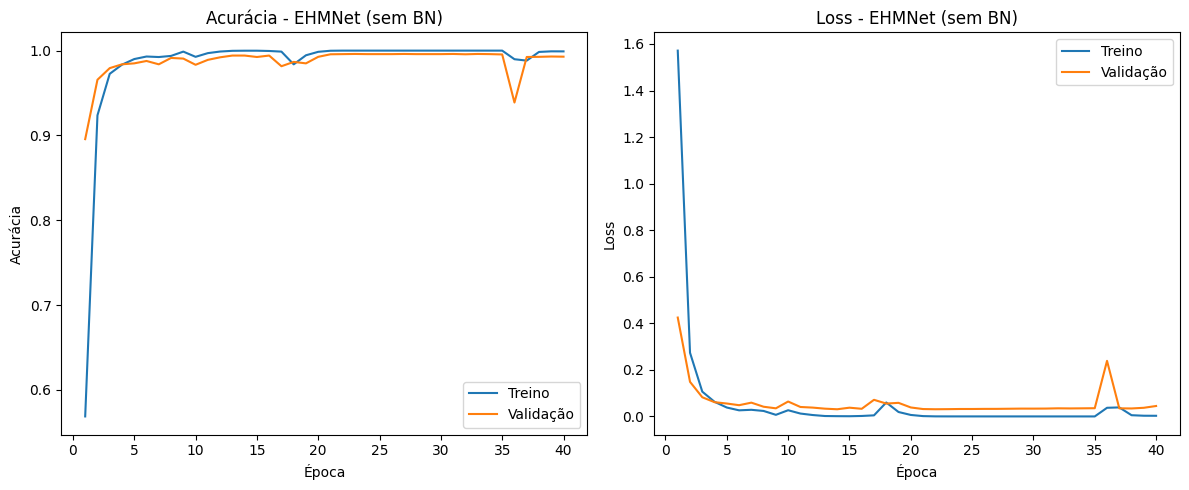

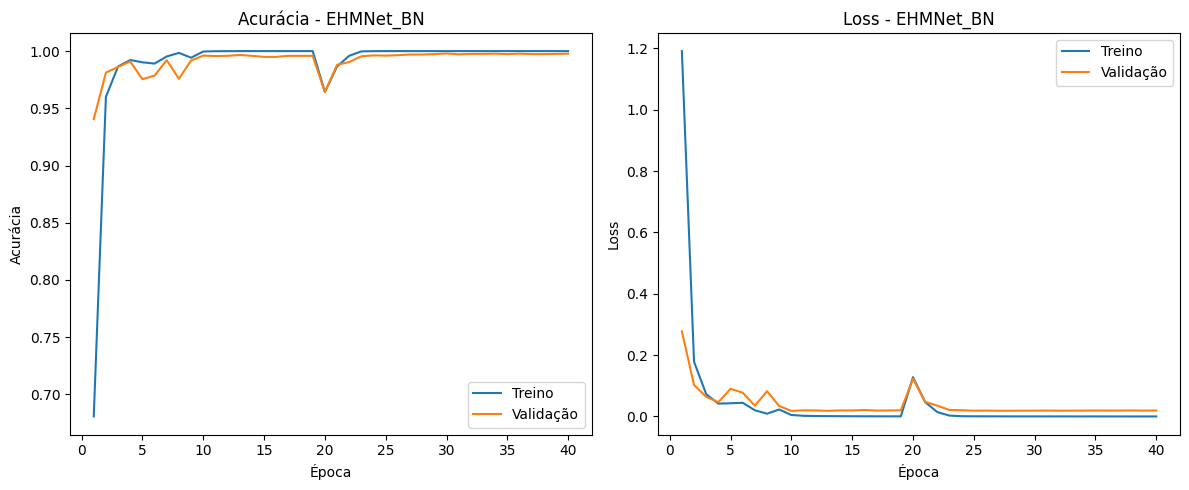

In [ ]:
def plot_overfitting_check(history, model_name):
    epochs = range(1, len(history['train_acc']) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_acc'], label='Treino')
    plt.plot(epochs, history['val_acc'], label='Validação')
    plt.xlabel('Época')
    plt.ylabel('Acurácia')
    plt.title(f'Acurácia - {model_name}')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_loss'], label='Treino')
    plt.plot(epochs, history['val_loss'], label='Validação')
    plt.xlabel('Época')
    plt.ylabel('Loss')
    plt.title(f'Loss - {model_name}')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f"figs2/overfitting_{model_name}_{NUM_EPOCHS}Epochs.png", dpi=150, bbox_inches='tight')
    plt.show()

plot_overfitting_check(res_no_bn["history"], "EHMNet (sem BN)")
plot_overfitting_check(res_bn["history"], "EHMNet_BN")


### (Opcional) Baixar os CSVs do Colab para a sua máquina

In [ ]:
from google.colab import files
files.download('predicoes_no_bn.csv')
files.download('predicoes_bn.csv')